<a href="https://colab.research.google.com/github/21anonymous/Advance-nuclear-physics-lab-/blob/main/deconvolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving 1.2 Cs.txt to 1.2 Cs (6).txt
[7319.]
1 generated successfully


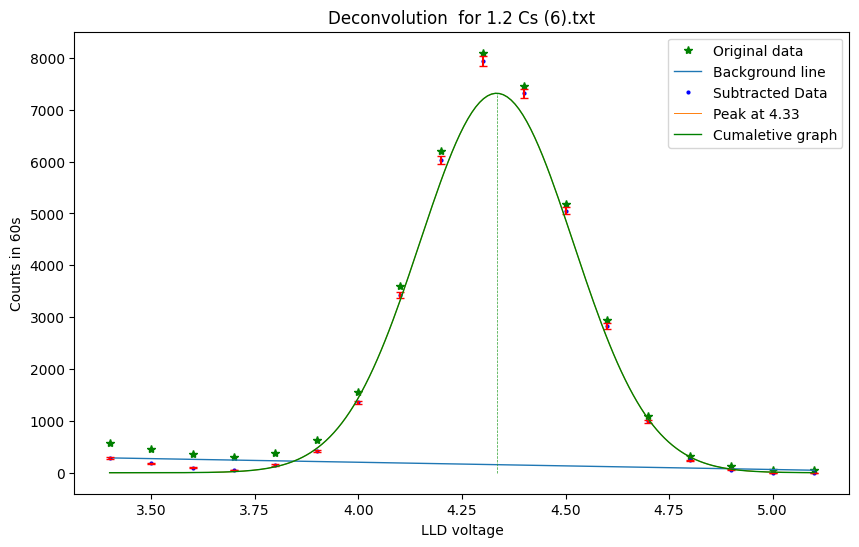

In [ ]:
!pip install peakutils #install package for better peak finding
import peakutils # Import the peakutils module
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.signal import find_peaks
import math
from datetime import datetime

# Define Gaussian function
def gaussian(x, a, mean, sigma):
    return a * np.exp(-((x - mean) ** 2) / (2 * sigma**2))

# Function to sum multiple Gaussians
def total_gaussian(x, amplitudes, means, sigmas):
    return sum(gaussian(x, a, m, s) for a, m, s in zip(amplitudes, means, sigmas))

# Chi-square function to minimize
def chi_square(params, x, y, y_err):
    amplitudes = params[:len(means)]
    fitted_means = params[len(means):2*len(means)]
    fitted_sigmas = params[2*len(means):]
    model = total_gaussian(x, amplitudes, fitted_means, fitted_sigmas)
    return np.sum(((y - model) / y_err) ** 2) / (len(y) - len(params))


# Function to read data from a file
def read_data(file):
    x_data, y_data = [], []
    try:
        with open(file, "r") as f:
            for line in f:
                if line.strip():
                    columns = line.split()
                    if len(columns) >= 2:
                        x_data.append(float(columns[0]))
                        y_data.append(float(columns[1]))
                    else:
                        print(f"Warning: Skipping line (not enough data): {line.strip()}")
    except FileNotFoundError:
        print(f"Error: The file {file} was not found.")
        return np.array([]), np.array([])

    return np.array(x_data), np.array(y_data)

def line_fit(x, y):
    x_mean, y_mean = np.mean(x), np.mean(y)
    slope = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
    intercept = y_mean - slope * x_mean
    return slope, intercept
# Read data from the file
#first name should be source and at least have four word in file name seperated by _
# Get file name from user input
# Upload file
uploaded = files.upload()

# Get the uploaded file name
file_name = list(uploaded.keys())[0]

# Read data from the uploaded file
x_data, y_data_1 = read_data(file_name)

solid_angles=np.array([5.78,1.76])
means = [4.4]  # Example values
sigmas = [ 0.18]
decay_fraction=[0.99]
#Enter manufacture date or T0
start_date = datetime(2005, 8, 1)#(YYYY, MM, DD)
current_date = datetime.today()
days_difference = (current_date - start_date).days
years_diff = days_difference / 365.25

a0=18.5*(10**4)#Initial activity in Bq
t_half=30.17# Half life of source in years
# decay_frac=[0.99]
at=a0*np.exp(-(0.693*years_diff)/t_half)

#The variable 'files' was overwriten. Re-assigning it to the intended value
files=[file_name]
for file,solid_angle in zip(files,solid_angles):
    # print(f"For the {file.split('_')[0]} {file.split('_')[2]} {file.split('_')[3]}\n")
    x_data, y_data_1= read_data(file)
    y_err = np.sqrt(y_data_1)  # error bars sqrt(N)
    #output=f"{file.split('_')[0]}_{file.split('_')[2]}_{file.split('_')[3]}" #This line is causing the error
    output = file.split('.')[0] #Change this line to extract the output file name.

    # Find the indices of the two lowest points near the peak region
    peak_index = np.argmin(np.abs(x_data - means[0]))  # Index of the peak

    # Define a window around the peak to search for lowest points
    window_size = 10  # Adjust this value as needed

    # Get the indices within the window
    window_indices = np.arange(max(0, peak_index - window_size),
                               min(len(x_data), peak_index + window_size + 1))

    # Find the indices of the two lowest points within the window
    sorted_indices = np.argsort(y_data_1[window_indices])
    lowest_indices = window_indices[sorted_indices[:2]]

    # Fit the background line using the two lowest points
    x1 = x_data[lowest_indices]
    y1 = y_data_1[lowest_indices]
    slope, intercept = line_fit(x1, y1)
    y_background = slope * x_data + intercept

    y_data=np.maximum(y_data_1-abs(y_background),1e-5) #Fixed indentation
    # peaks_new, _ = find_peaks(y_data, prominence=max(y_bg)*0.1,wlen=10)
    plt.figure(figsize=(10, 6))
    plt.plot(x_data,y_data_1,"g*" ,label='Original data', linewidth=1)
    plt.plot(x_data,y_background ,label='Background line', linewidth=1)
    p=[np.argmin(abs(x_data-m))for m in means]
    peaks_new=y_data[p]
    print(peaks_new)
    #Parameter bounding
    mean_bounds = [(m - m*0.05, m + m*0.05) for m in means] # 5% around mean and sigma
    sigma_bounds = [(s - s*0.10, s + s*0.10) for s in sigmas]
    amplitude_bounds = [(0, pv) for pv in peaks_new]
    initial_guess = np.concatenate([np.full(len(means), max(y_data)), means, sigmas])
    bound = amplitude_bounds + mean_bounds + sigma_bounds
    # Optimize amplitudes
    result = minimize(chi_square, initial_guess, args=(x_data, y_data, y_err), method='L-BFGS-B', bounds=bound)
    optimized_amplitudes = result.x[:len(means)]
    optimized_means = result.x[len(means):2*len(means)]
    optimized_sigmas = result.x[2*len(means):]

    # Plot results
    y_bar=np.sqrt(y_data)
    # plt.scatter(x_data, y_data, label='Subtracted Data', linewidth=0.5,color='black')
    plt.plot(x_data, y_data, "bo", label='Subtracted Data',markersize=2)
    plt.errorbar(x_data, y_data, yerr=y_bar, fmt="o", color="red", markersize=0.1, capsize=3)
    y_smooth=np.zeros(len(x_data)*10)
    x_smooth=np.linspace(min(x_data),max(x_data),len(x_data)*10)
    with open(output, 'w') as out_file:
      out_file.write(f"{file}\n")
      out_file.write(f"\nHalf life of source= {t_half:.2f} years\n")
      out_file.write(f"Start Date: {start_date}\n")
      out_file.write(f"Current Date: {current_date}\n")
      out_file.write(f"Initial activity of the source= {a0:.2f} Bq\n")
      out_file.write(f"Time difference(t0-t) = {years_diff:.2f} years\n")
      out_file.write(f"Current Activity of the source= {at:.2f} Bq\n\n")
      for a, m, s ,df in zip(optimized_amplitudes, optimized_means,optimized_sigmas,decay_fraction):
          y_new= gaussian(x_data, a, m, s)
          plt.plot(x_smooth, gaussian(x_smooth, a, m, s),linewidth=0.7, label=f'Peak at {m:.2f}')
          y_smooth=y_smooth+gaussian(x_smooth, a, m, s)
          area=np.sum(gaussian(x_data, a, m, s))
          abs_eff=area/(60*at*df)
          intrinsic_eff=abs_eff*((4*math.pi)/(solid_angle))
          out_file.write(f"\nArea under the Peak ={m} is = {area/60:.2f} per second\n")
          out_file.write(f"Decay fraction is ={df}\n")
          out_file.write(f"Solid angle is ={solid_angle} in sr\n")
          out_file.write(f"No of particle emitted by  the source= {at*df:.2f} per second\n")
          out_file.write(f"Absolute efficiency is = {abs_eff*100:.4f} %\n")
          out_file.write(f"No of particle incident on detector= {(at*df*solid_angle)/(math.pi*60):.2f} per second\n")
          out_file.write(f"Intrinsic efficiency is = {intrinsic_eff*100:.4f} %\n\n")
          out_file.write("#Voltage;Count;Background;subtracted data;fitted peak\n")
          for i in range(0, len(x_data),1):
             out_file.write(f"{x_data[i]:.1f};{y_data_1 [i]:.0f};{y_background[i]:.0f};{y_data[i]:.0f};{y_new[i]:.0f}\n")
          plt.plot([m,m],[0,a], linestyle='--', linewidth=0.5)
    plt.plot(x_smooth,y_smooth, label='Cumaletive graph', color='green', linewidth=1)
    plt.xlabel('LLD voltage')
    plt.ylabel('Counts in 60s')
    plt.title(f'Deconvolution  for {file}')
    plt.legend()
    plt.savefig(f"137Cs_solid_angle{solid_angle}.png", format='png', dpi=300,transparent=False)
    print(f"{output} generated successfully")
plt.show()

Upload the first file:


Saving 1.2 Cs.txt to 1.2 Cs (8).txt

Upload the second file:


Saving Cs.txt to Cs (13).txt
[7319.]


<ipython-input-25-4c7c243e1754>:82: RankWarning: Polyfit may be poorly conditioned
  background_coeffs = np.polyfit(x1, y1, 1)


1 generated successfully


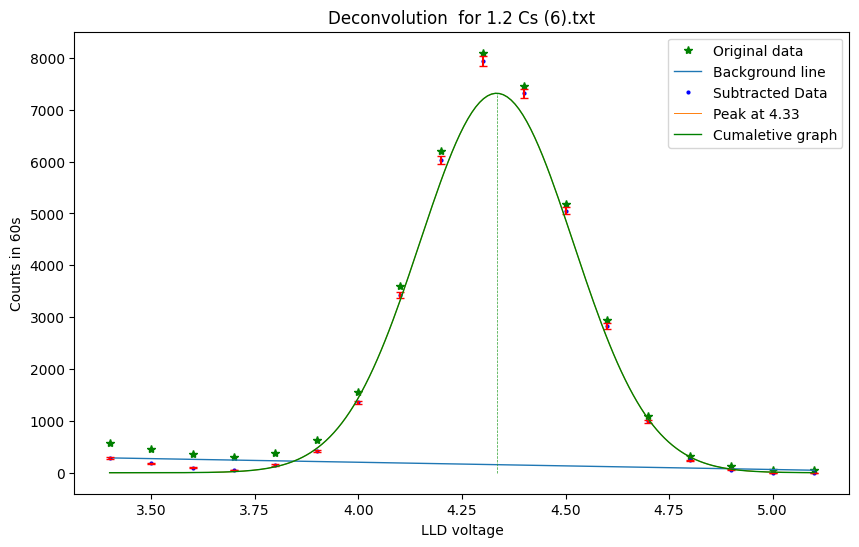

In [ ]:
!pip install peakutils #install package for better peak finding
import peakutils # Import the peakutils module
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.signal import find_peaks
import math
from datetime import datetime
# Define Gaussian function
def gaussian(x, a, mean, sigma):
    return a * np.exp(-((x - mean) ** 2) / (2 * sigma**2))

# Function to sum multiple Gaussians
def total_gaussian(x, amplitudes, means, sigmas):
    return sum(gaussian(x, a, m, s) for a, m, s in zip(amplitudes, means, sigmas))

# Chi-square function to minimize
def chi_square(params, x, y, y_err):
    amplitudes = params[:len(means)]
    fitted_means = params[len(means):2*len(means)]
    fitted_sigmas = params[2*len(means):]
    model = total_gaussian(x, amplitudes, fitted_means, fitted_sigmas)
    return np.sum(((y - model) / y_err) ** 2) / (len(y) - len(params))


# Function to read data from a file
def read_data(file):
    x_data, y_data = [], []
    try:
        with open(file, "r") as f:
            for line in f:
                if line.strip():
                    columns = line.split()
                    if len(columns) >= 2:
                        x_data.append(float(columns[0]))
                        y_data.append(float(columns[1]))
                    else:
                        print(f"Warning: Skipping line (not enough data): {line.strip()}")
    except FileNotFoundError:
        print(f"Error: The file {file} was not found.")
        return np.array([]), np.array([])

    return np.array(x_data), np.array(y_data)

def line_fit(x, y):
    x_mean, y_mean = np.mean(x), np.mean(y)
    slope = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
    intercept = y_mean - slope * x_mean
    return slope, intercept
# Read data from the file
#first name should be source and at least have four word in file name seperated by _
# Get file name from user input
# Upload file
# --- Modified Section ---
solid_angles = np.array([2.6799, 0.6923])  # Assuming two solid angles

# Prompt for the first file
print("Upload the first file:")
uploaded_1 = files.upload()
file_name_1 = list(uploaded_1.keys())[0]

# Prompt for the second file
print("\nUpload the second file:")
uploaded_2 = files.upload()
file_name_2 = list(uploaded_2.keys())[0]

# Process each file
files = [file_name_1, file_name_2]
for file, solid_angle in zip(files, solid_angles):
    x_data, y_data_1 = read_data(file)
    y_err = np.sqrt(y_data_1)  # error bars sqrt(N)
    output = file.split('.')[0] #Change this line to extract the output file name.

    # --- Background Estimation using peakutils ---
    y_bg = np.abs(y_data_1 - max(y_data_1))
    indexes = peakutils.indexes(y_bg, thres=0.5, min_dist=30)

    # Fit background using polyfit with degree 1 (linear) using more points
    x1 = x_data[indexes]
    y1 = y_data_1[indexes]
    background_coeffs = np.polyfit(x1, y1, 1)
    y_background = np.polyval(background_coeffs, x_data)

    y_data = np.maximum(y_data_1 - abs(y_background), 1e-5)

means = [4.4]  # Example values
sigmas = [ 0.18]
decay_fraction=[0.99]
#Enter manufacture date or T0
start_date = datetime(2005, 8, 1)#(YYYY, MM, DD)
current_date = datetime.today()
days_difference = (current_date - start_date).days
years_diff = days_difference / 365.25

a0=18.5*(10**4)#Initial activity in Bq
t_half=30.17# Half life of source in years
# decay_frac=[0.99]
at=a0*np.exp(-(0.693*years_diff)/t_half)

#The variable 'files' was overwriten. Re-assigning it to the intended value
files=[file_name]
for file,solid_angle in zip(files,solid_angles):
    # print(f"For the {file.split('_')[0]} {file.split('_')[2]} {file.split('_')[3]}\n")
    x_data, y_data_1= read_data(file)
    y_err = np.sqrt(y_data_1)  # error bars sqrt(N)
    #output=f"{file.split('_')[0]}_{file.split('_')[2]}_{file.split('_')[3]}" #This line is causing the error
    output = file.split('.')[0] #Change this line to extract the output file name.

    # Find the indices of the two lowest points near the peak region
    peak_index = np.argmin(np.abs(x_data - means[0]))  # Index of the peak

    # Define a window around the peak to search for lowest points
    window_size = 10  # Adjust this value as needed

    # Get the indices within the window
    window_indices = np.arange(max(0, peak_index - window_size),
                               min(len(x_data), peak_index + window_size + 1))

    # Find the indices of the two lowest points within the window
    sorted_indices = np.argsort(y_data_1[window_indices])
    lowest_indices = window_indices[sorted_indices[:2]]

    # Fit the background line using the two lowest points
    x1 = x_data[lowest_indices]
    y1 = y_data_1[lowest_indices]
    slope, intercept = line_fit(x1, y1)
    y_background = slope * x_data + intercept

    y_data=np.maximum(y_data_1-abs(y_background),1e-5) #Fixed indentation
    # peaks_new, _ = find_peaks(y_data, prominence=max(y_bg)*0.1,wlen=10)
    plt.figure(figsize=(10, 6))
    plt.plot(x_data,y_data_1,"g*" ,label='Original data', linewidth=1)
    plt.plot(x_data,y_background ,label='Background line', linewidth=1)
    p=[np.argmin(abs(x_data-m))for m in means]
    peaks_new=y_data[p]
    print(peaks_new)
    #Parameter bounding
    mean_bounds = [(m - m*0.05, m + m*0.05) for m in means] # 5% around mean and sigma
    sigma_bounds = [(s - s*0.10, s + s*0.10) for s in sigmas]
    amplitude_bounds = [(0, pv) for pv in peaks_new]
    initial_guess = np.concatenate([np.full(len(means), max(y_data)), means, sigmas])
    bound = amplitude_bounds + mean_bounds + sigma_bounds
    # Optimize amplitudes
    result = minimize(chi_square, initial_guess, args=(x_data, y_data, y_err), method='L-BFGS-B', bounds=bound)
    optimized_amplitudes = result.x[:len(means)]
    optimized_means = result.x[len(means):2*len(means)]
    optimized_sigmas = result.x[2*len(means):]

    # Plot results
    y_bar=np.sqrt(y_data)
    # plt.scatter(x_data, y_data, label='Subtracted Data', linewidth=0.5,color='black')
    plt.plot(x_data, y_data, "bo", label='Subtracted Data',markersize=2)
    plt.errorbar(x_data, y_data, yerr=y_bar, fmt="o", color="red", markersize=0.1, capsize=3)
    y_smooth=np.zeros(len(x_data)*10)
    x_smooth=np.linspace(min(x_data),max(x_data),len(x_data)*10)
    with open(output, 'w') as out_file:
      out_file.write(f"{file}\n")
      out_file.write(f"\nHalf life of source= {t_half:.2f} years\n")
      out_file.write(f"Start Date: {start_date}\n")
      out_file.write(f"Current Date: {current_date}\n")
      out_file.write(f"Initial activity of the source= {a0:.2f} Bq\n")
      out_file.write(f"Time difference(t0-t) = {years_diff:.2f} years\n")
      out_file.write(f"Current Activity of the source= {at:.2f} Bq\n\n")
      for a, m, s ,df in zip(optimized_amplitudes, optimized_means,optimized_sigmas,decay_fraction):
          y_new= gaussian(x_data, a, m, s)
          plt.plot(x_smooth, gaussian(x_smooth, a, m, s),linewidth=0.7, label=f'Peak at {m:.2f}')
          y_smooth=y_smooth+gaussian(x_smooth, a, m, s)
          area=np.sum(gaussian(x_data, a, m, s))
          abs_eff=area/(60*at*df)
          intrinsic_eff=abs_eff*((4*math.pi)/(solid_angle))
          out_file.write(f"\nArea under the Peak ={m} is = {area/60:.2f} per second\n")
          out_file.write(f"Decay fraction is ={df}\n")
          out_file.write(f"Solid angle is ={solid_angle} in sr\n")
          out_file.write(f"No of particle emitted by  the source= {at*df:.2f} per second\n")
          out_file.write(f"Absolute efficiency is = {abs_eff*100:.4f} %\n")
          out_file.write(f"No of particle incident on detector= {(at*df*solid_angle)/(math.pi*60):.2f} per second\n")
          out_file.write(f"Intrinsic efficiency is = {intrinsic_eff*100:.4f} %\n\n")
          out_file.write("#Voltage;Count;Background;subtracted data;fitted peak\n")
          for i in range(0, len(x_data),1):
             out_file.write(f"{x_data[i]:.1f};{y_data_1 [i]:.0f};{y_background[i]:.0f};{y_data[i]:.0f};{y_new[i]:.0f}\n")
          plt.plot([m,m],[0,a], linestyle='--', linewidth=0.5)
    plt.plot(x_smooth,y_smooth, label='Cumaletive graph', color='green', linewidth=1)
    plt.xlabel('LLD voltage')
    plt.ylabel('Counts in 60s')
    plt.title(f'Deconvolution  for {file}')
    plt.legend()
    plt.savefig(f"137Cs_solid_angle{solid_angle}.png", format='png', dpi=300,transparent=False)
    print(f"{output} generated successfully")
plt.show()